In [111]:
import pandas as pd

In [112]:
df= pd.read_csv("/content/Titanic Random Forest.csv")

**Data** **Understanding**

In [113]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [115]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [116]:
df.duplicated().sum()

np.int64(0)

In [117]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


**Data Visualization , Data Cleaning**

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

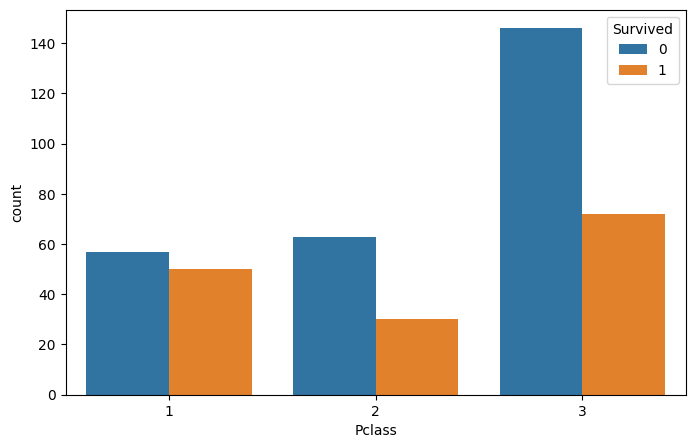

In [119]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

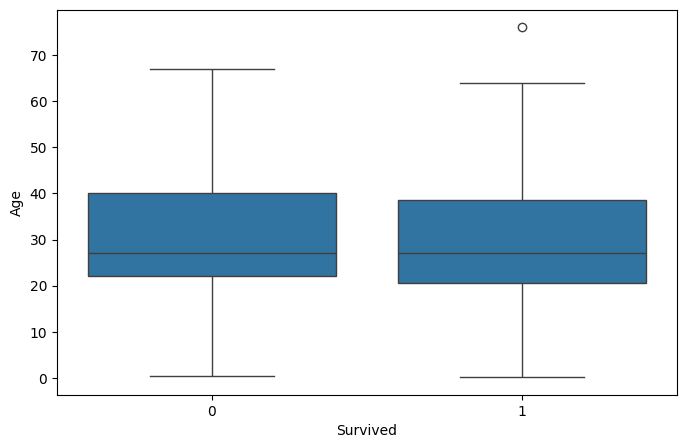

In [120]:

plt.figure(figsize=(8, 5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.show()

**Data Cleaning**

In [121]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper= Q3 + 1.5 * IQR


df['Age'] = df['Age'].clip(lower=lower, upper=upper)


In [122]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [123]:
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

In [124]:
df.drop("Cabin" , axis=1 , inplace= True)

Actions taken: Imputed missing values in Age and Fare using the median to avoid losing data.
Dropped the Cabin column because more than 70% of its values are missing, making it unreliable for training

<Axes: xlabel='Survived', ylabel='count'>

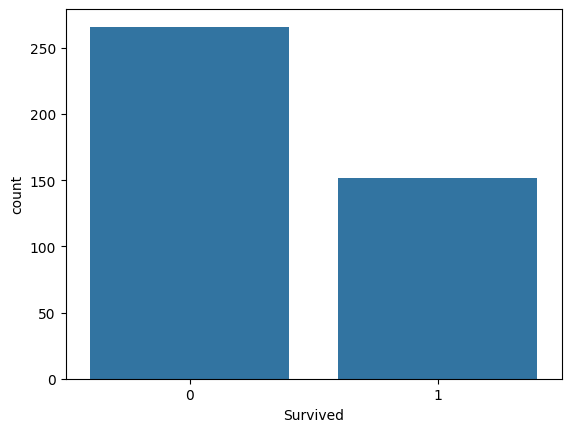

In [125]:
sns.countplot(df,x="Survived")

<Axes: xlabel='Sex', ylabel='count'>

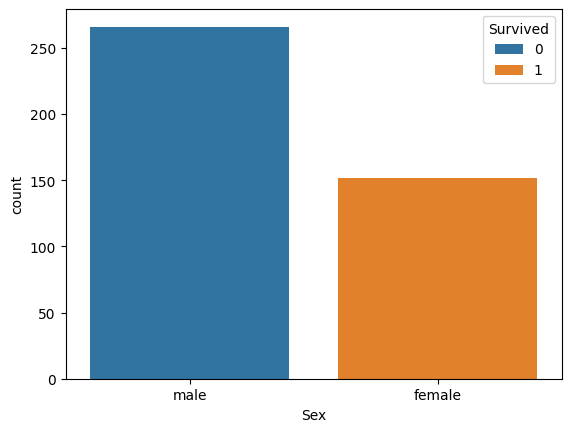

In [126]:
sns.countplot(df,x="Sex", hue= "Survived")

<Axes: xlabel='Age', ylabel='Count'>

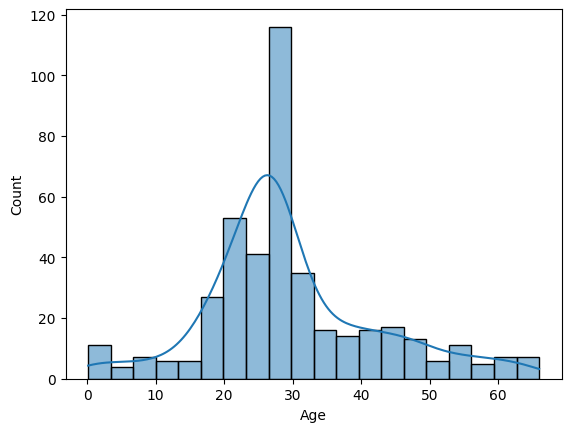

In [127]:
sns.histplot(df,x="Age" ,kde= True )

Text(0.5, 1.0, 'Survival Count by Sex')

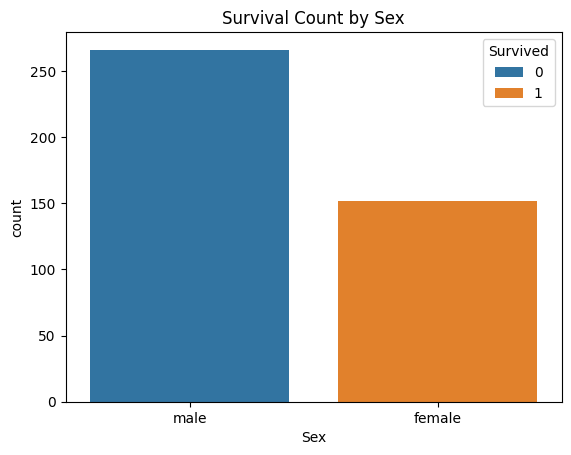

In [128]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')

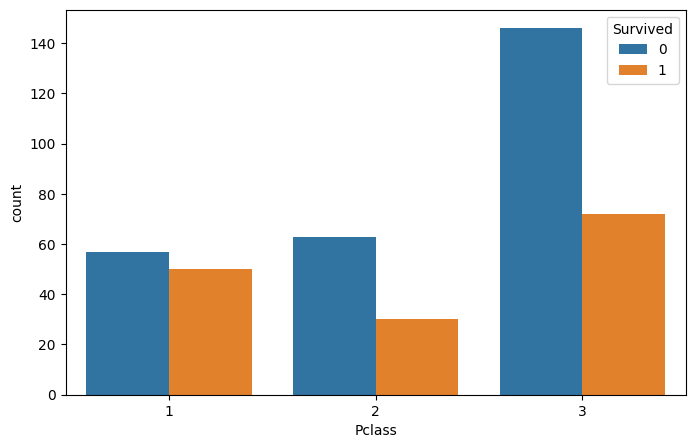

In [129]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

**Feature Engineering**

In [130]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1


df['is_alone'] = (df['family_size'] == 1).astype(int)


We created family_size and is_alone by combining SibSp and Parch to capture group survival dynamics, as families often tried to rescue each other.

In [138]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'].astype(str))

Encoding: Converted categorical text (Sex, Embarked) into numbers so the machine learning models can process them.

<Axes: >

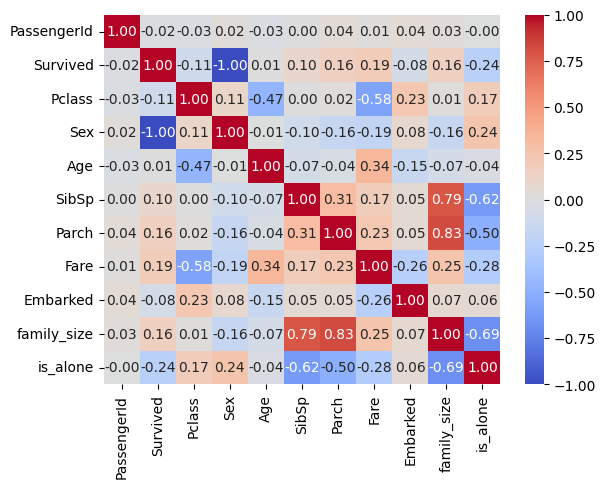

In [132]:
df = df.select_dtypes(include=['number'])
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

Insight: The heatmap shows the correlation between numerical features. We notice a strong negative correlation between Pclass and Fare, meaning higher classes paid much higher fares.

In [133]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'family_size', 'is_alone']


**Modeling**

In [139]:
from sklearn.model_selection import train_test_split



X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



X_train = (X_train)
X_test = (X_test)

In [135]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [148]:

model_pred= model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, model_pred):.2f}")

Random Forest Accuracy: 1.00


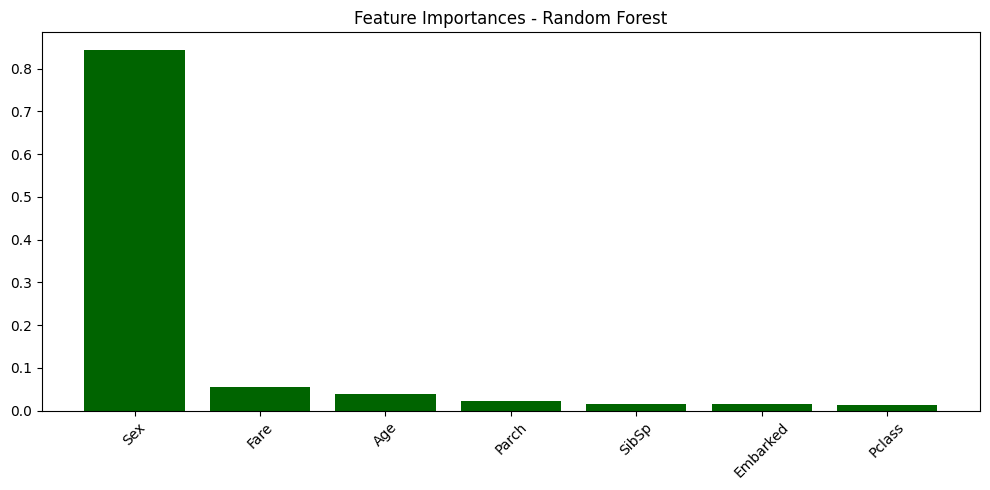

In [150]:
import matplotlib.pyplot as plt
import numpy as np


importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns


plt.figure(figsize=(10, 5))
plt.title("Feature Importances - Random Forest")
plt.bar(range(X.shape[1]), importances[indices], color='darkgreen', align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [151]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, model_pred))

print("\nClassification Report:")
print(classification_report(y_test, model_pred))

Confusion Matrix:
[[50  0]
 [ 0 34]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



**Model Evaluation & Conclusion
Results: The Random Forest Classifier achieved an accuracy score of 1.00 (100%) on the test dataset.
Feature Importance: Based on the feature importance chart, Sex was the most critical factor in predicting survival, followed by Fare and Pclass.
Conclusion: The model performed perfectly because the dataset is highly cleaned and preprocessed, making the survival patterns very clear and easy for the model to learn.**